In [1]:
import sympy as sp
import numba as nb
import numpy as np
import cv2
import yaml
import matplotlib.pyplot as plt
import cmasher
from pathlib import Path
from timeit import timeit

## Derive mapping functions

In [2]:
symbol_x_trans, symbol_y_trans = sp.symbols("x_t y_t")
symbol_row_behavior, symbol_col_behavior = sp.symbols("r_b c_b")
symbol_row_muscle, symbol_col_muscle = sp.symbols("r_m c_m")
symbol_x_phys, symbol_y_phys = sp.symbols("x_p y_p")

variables_behavior_stage_px_to_x_phys = sp.symbols("u_0 u_1 u_2 u_3 u_4")
variables_behavior_stage_px_to_y_phys = sp.symbols("v_0 v_1 v_2 v_3 v_4")
variables_muscle_stage_px_to_x_phys = sp.symbols("w_0 w_1 w_2 w_3 w_4")
variables_muscle_stage_px_to_y_phys = sp.symbols("k_0 k_1 k_2 k_3 k_4")

matrix_behavior_stage_px_to_phys = sp.Matrix(
    [variables_behavior_stage_px_to_x_phys, variables_behavior_stage_px_to_y_phys]
)
matrix_muscle_stage_px_to_phys = sp.Matrix(
    [variables_muscle_stage_px_to_x_phys, variables_muscle_stage_px_to_y_phys]
)

vector_phys = sp.Matrix([symbol_x_phys, symbol_y_phys])
vector_inputs_behavior_stage_px_to_phys = sp.Matrix(
    [1, symbol_x_trans, symbol_y_trans, symbol_row_behavior, symbol_col_behavior]
)
vector_inputs_muscle_stage_px_to_phys = sp.Matrix(
    [1, symbol_x_trans, symbol_y_trans, symbol_row_muscle, symbol_col_muscle]
)

In [3]:
equation_behavior = (
    vector_phys
    - matrix_behavior_stage_px_to_phys * vector_inputs_behavior_stage_px_to_phys
)
equation_muscle = (
    vector_phys
    - matrix_muscle_stage_px_to_phys * vector_inputs_muscle_stage_px_to_phys
)

In [4]:
solution = sp.solve((equation_behavior, equation_muscle), (symbol_row_muscle, symbol_col_muscle))

In [5]:
solution[symbol_row_muscle].simplify()

(-k_0*w_4 - k_1*w_4*x_t - k_2*w_4*y_t + k_4*w_0 + k_4*w_1*x_t + k_4*w_2*y_t - k_4*x_p + w_4*y_p)/(k_3*w_4 - k_4*w_3)

In [6]:
solution[symbol_col_muscle].simplify()

(k_0*w_3 + k_1*w_3*x_t + k_2*w_3*y_t - k_3*w_0 - k_3*w_1*x_t - k_3*w_2*y_t + k_3*x_p - w_3*y_p)/(k_3*w_4 - k_4*w_3)

## Load calibration parameters

In [7]:
class MuscleToBehaviorMapping:
    name_to_symbol = {
        "behavior_cam/physical_pos_x/bias": "u_0",
        "behavior_cam/physical_pos_x/stage_pos_x": "u_1",
        "behavior_cam/physical_pos_x/stage_pos_y": "u_2",
        "behavior_cam/physical_pos_x/pixel_pos_col": "u_3",
        "behavior_cam/physical_pos_x/pixel_pos_row": "u_4",
        "behavior_cam/physical_pos_y/bias": "v_0",
        "behavior_cam/physical_pos_y/stage_pos_x": "v_1",
        "behavior_cam/physical_pos_y/stage_pos_y": "v_2",
        "behavior_cam/physical_pos_y/pixel_pos_col": "v_3",
        "behavior_cam/physical_pos_y/pixel_pos_row": "v_4",
        "muscle_cam/physical_pos_x/bias": "w_0",
        "muscle_cam/physical_pos_x/stage_pos_x": "w_1",
        "muscle_cam/physical_pos_x/stage_pos_y": "w_2",
        "muscle_cam/physical_pos_x/pixel_pos_col": "w_3",
        "muscle_cam/physical_pos_x/pixel_pos_row": "w_4",
        "muscle_cam/physical_pos_y/bias": "k_0",
        "muscle_cam/physical_pos_y/stage_pos_x": "k_1",
        "muscle_cam/physical_pos_y/stage_pos_y": "k_2",
        "muscle_cam/physical_pos_y/pixel_pos_col": "k_3",
        "muscle_cam/physical_pos_y/pixel_pos_row": "k_4",
    }
    symbol_to_name = {v: k for k, v in name_to_symbol.items()}

    def __init__(self, calibration_data_dir):
        self.calibration_data_dir = calibration_data_dir
        self.behavior_calibration_path = (
            calibration_data_dir / "model/behavior_camera/calibration_result.yaml"
        )
        self.muscle_calibration_path = (
            calibration_data_dir / "model/muscle_camera/calibration_result.yaml"
        )
        self.params_stage_px_to_phys = {}
        with open(self.behavior_calibration_path, "r") as f:
            params = yaml.safe_load(f)["stage_and_pixel_to_physical"]
            self.params_stage_px_to_phys["behavior_cam"] = params
        with open(self.muscle_calibration_path, "r") as f:
            params = yaml.safe_load(f)["stage_and_pixel_to_physical"]
            self.params_stage_px_to_phys["muscle_cam"] = params

        self.behavior_weights_stage_px_to_phys_x = np.array(
            [self.get_param(f"u_{i}") for i in range(5)]
        )
        self.behavior_weights_stage_px_to_phys_y = np.array(
            [self.get_param(f"v_{i}") for i in range(5)]
        )
        self.muscle_weights_stage_px_to_phys_x = np.array(
            [self.get_param(f"w_{i}") for i in range(5)]
        )
        self.muscle_weights_stage_px_to_phys_y = np.array(
            [self.get_param(f"k_{i}") for i in range(5)]
        )

    def get_param(self, name):
        if name in self.name_to_symbol:
            pass
        elif name in self.symbol_to_name:
            name = self.symbol_to_name[name]
        else:
            raise ValueError(f"Unknown parameter name: {name}")
        cam_name, target_var, input_var = name.split("/")
        return self.params_stage_px_to_phys[cam_name][target_var][input_var]

In [8]:
calibration_data_dir = Path(
    "~/Data/spotlight/20250502-fly01-002-grade2/sibo/calibration/"
).expanduser()
mapping = MuscleToBehaviorMapping(calibration_data_dir)

## Transform image

In [9]:
behavior_image_example_path = Path(
    "~/Data/spotlight/20250502-fly01-002-grade2/behavior_images/behavior_frame_000000000.jpg"
).expanduser()
muscle_image_example_path = Path(
    "~/Data/spotlight/20250502-fly01-002-grade2/muscle_images/muscle_frame_000000000.tif"
).expanduser()
assert behavior_image_example_path.exists()
assert muscle_image_example_path.exists()

In [10]:
behavior_image_example = cv2.imread(str(behavior_image_example_path))
assert len(behavior_image_example.shape) == 3 and behavior_image_example.shape[2] == 3
behavior_image_example = behavior_image_example[:, :, 0]

In [11]:
muscle_image_example = cv2.imread(str(muscle_image_example_path), cv2.IMREAD_UNCHANGED)
assert len(muscle_image_example.shape) == 2
assert muscle_image_example.dtype == np.uint16
assert muscle_image_example.max() > 0

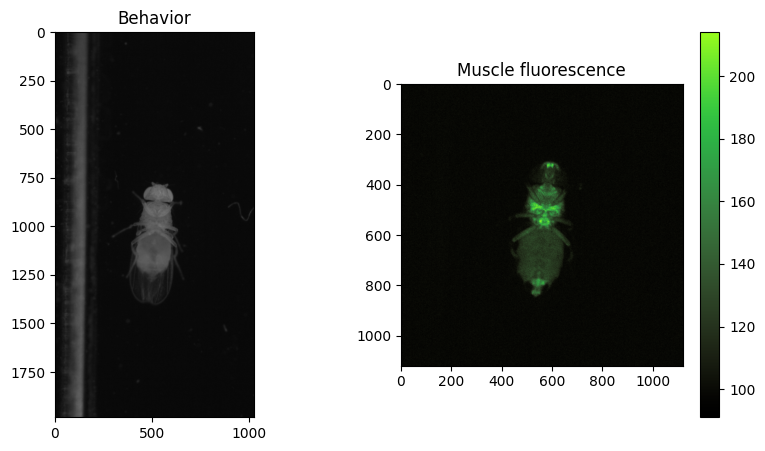

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(behavior_image_example, cmap="gray", vmin=0, vmax=255)
muscle_q1 = np.percentile(muscle_image_example.flatten(), 1)
muscle_q9999 = np.percentile(muscle_image_example.flatten(), 99.99)
muscle_plot = axes[1].imshow(
    muscle_image_example, cmap=cmasher.nuclear, vmin=muscle_q1, vmax=muscle_q9999
)
axes[0].set_title("Behavior")
axes[1].set_title("Muscle fluorescence")
plt.colorbar(muscle_plot)

In [13]:
x_stage_mean = np.float32((68 + 115) / 2)
y_stage_mean = np.float32((47 + 113) / 2)

In [14]:
def get_muscle_px_coords(
    x_stage,
    y_stage,
    row_behavior,
    col_behavior,
    behavior_weights_for_x_phys,
    behavior_weights_for_y_phys,
    muscle_weights_for_x_phys,
    muscle_weights_for_y_phys,
):
    x_phys = (
        behavior_weights_for_x_phys[0]
        + (behavior_weights_for_x_phys[1] * x_stage)
        + (behavior_weights_for_x_phys[2] * y_stage)
        + (behavior_weights_for_x_phys[3] * row_behavior)
        + (behavior_weights_for_x_phys[4] * col_behavior)
    )
    y_phys = (
        behavior_weights_for_y_phys[0]
        + (behavior_weights_for_y_phys[1] * x_stage)
        + (behavior_weights_for_y_phys[2] * y_stage)
        + (behavior_weights_for_y_phys[3] * row_behavior)
        + (behavior_weights_for_y_phys[4] * col_behavior)
    )
    
    denominator = (
        (muscle_weights_for_y_phys[3] * (muscle_weights_for_x_phys[4]))
        - (muscle_weights_for_y_phys[4] * muscle_weights_for_x_phys[3])
    )
    row_muscle = (
        -(muscle_weights_for_y_phys[0] * muscle_weights_for_x_phys[4])
        - (muscle_weights_for_y_phys[1] * muscle_weights_for_x_phys[4] * x_stage)
        - (muscle_weights_for_y_phys[2] * muscle_weights_for_x_phys[4] * y_stage)
        + (muscle_weights_for_y_phys[4] * muscle_weights_for_x_phys[0])
        + (muscle_weights_for_y_phys[4] * muscle_weights_for_x_phys[1] * x_stage)
        + (muscle_weights_for_y_phys[4] * muscle_weights_for_x_phys[2] * y_stage)
        - (muscle_weights_for_y_phys[4] * x_phys)
        + (muscle_weights_for_x_phys[4] * y_phys)
    ) / denominator
    col_muscle = (
        (muscle_weights_for_y_phys[0] * muscle_weights_for_x_phys[3])
        + (muscle_weights_for_y_phys[1] * muscle_weights_for_x_phys[3] * x_stage)
        + (muscle_weights_for_y_phys[2] * muscle_weights_for_x_phys[3] * y_stage)
        - (muscle_weights_for_y_phys[3] * muscle_weights_for_x_phys[0])
        - (muscle_weights_for_y_phys[3] * muscle_weights_for_x_phys[1] * x_stage)
        - (muscle_weights_for_y_phys[3] * muscle_weights_for_x_phys[2] * y_stage)
        + (muscle_weights_for_y_phys[3] * x_phys)
        - (muscle_weights_for_x_phys[3] * y_phys)
    ) / denominator
    
    return row_muscle, col_muscle


def map_muscle_to_behavior(
    muscle_image,
    behavior_image_dim,
    x_stage,
    y_stage,
    behavior_weights_for_x_phys,
    behavior_weights_for_y_phys,
    muscle_weights_for_x_phys,
    muscle_weights_for_y_phys,
):
    mapped_muscle_image = np.full(behavior_image_dim, np.nan, dtype=muscle_image.dtype)
    for i in range(behavior_image_dim[0]):
        for j in range(behavior_image_dim[1]):
            muscle_i, muscle_j = get_muscle_px_coords(
                x_stage,
                y_stage,
                i,
                j,
                behavior_weights_for_x_phys,
                behavior_weights_for_y_phys,
                muscle_weights_for_x_phys,
                muscle_weights_for_y_phys,
            )
            muscle_i = int(muscle_i)
            muscle_j = int(muscle_j)
            if (
                0 <= muscle_i < muscle_image.shape[0]
                and 0 <= muscle_j < muscle_image.shape[1]
            ):
                mapped_muscle_image[i, j] = muscle_image[muscle_i, muscle_j]
    return mapped_muscle_image

In [15]:
@nb.jit(nopython=True, fastmath=True)
def get_muscle_px_coords_jit(
    x_stage,
    y_stage,
    row_behavior,
    col_behavior,
    behavior_weights_for_x_phys,
    behavior_weights_for_y_phys,
    muscle_weights_for_x_phys,
    muscle_weights_for_y_phys,
):
    x_phys = (
        behavior_weights_for_x_phys[0]
        + (behavior_weights_for_x_phys[1] * x_stage)
        + (behavior_weights_for_x_phys[2] * y_stage)
        + (behavior_weights_for_x_phys[3] * row_behavior)
        + (behavior_weights_for_x_phys[4] * col_behavior)
    )
    y_phys = (
        behavior_weights_for_y_phys[0]
        + (behavior_weights_for_y_phys[1] * x_stage)
        + (behavior_weights_for_y_phys[2] * y_stage)
        + (behavior_weights_for_y_phys[3] * row_behavior)
        + (behavior_weights_for_y_phys[4] * col_behavior)
    )
    
    denominator = (
        (muscle_weights_for_y_phys[3] * (muscle_weights_for_x_phys[4]))
        - (muscle_weights_for_y_phys[4] * muscle_weights_for_x_phys[3])
    )
    row_muscle = (
        -(muscle_weights_for_y_phys[0] * muscle_weights_for_x_phys[4])
        - (muscle_weights_for_y_phys[1] * muscle_weights_for_x_phys[4] * x_stage)
        - (muscle_weights_for_y_phys[2] * muscle_weights_for_x_phys[4] * y_stage)
        + (muscle_weights_for_y_phys[4] * muscle_weights_for_x_phys[0])
        + (muscle_weights_for_y_phys[4] * muscle_weights_for_x_phys[1] * x_stage)
        + (muscle_weights_for_y_phys[4] * muscle_weights_for_x_phys[2] * y_stage)
        - (muscle_weights_for_y_phys[4] * x_phys)
        + (muscle_weights_for_x_phys[4] * y_phys)
    ) / denominator
    col_muscle = (
        (muscle_weights_for_y_phys[0] * muscle_weights_for_x_phys[3])
        + (muscle_weights_for_y_phys[1] * muscle_weights_for_x_phys[3] * x_stage)
        + (muscle_weights_for_y_phys[2] * muscle_weights_for_x_phys[3] * y_stage)
        - (muscle_weights_for_y_phys[3] * muscle_weights_for_x_phys[0])
        - (muscle_weights_for_y_phys[3] * muscle_weights_for_x_phys[1] * x_stage)
        - (muscle_weights_for_y_phys[3] * muscle_weights_for_x_phys[2] * y_stage)
        + (muscle_weights_for_y_phys[3] * x_phys)
        - (muscle_weights_for_x_phys[3] * y_phys)
    ) / denominator
    
    return row_muscle, col_muscle

@nb.jit(nopython=True, parallel=True, nogil=True, fastmath=True)
def map_muscle_to_behavior_jit(
    muscle_image,
    behavior_image_dim,
    x_stage,
    y_stage,
    behavior_weights_for_x_phys,
    behavior_weights_for_y_phys,
    muscle_weights_for_x_phys,
    muscle_weights_for_y_phys,
):
    mapped_muscle_image = np.full(behavior_image_dim, np.nan, dtype=muscle_image.dtype)
    for i in nb.prange(behavior_image_dim[0]):
        for j in range(behavior_image_dim[1]):
            muscle_i, muscle_j = get_muscle_px_coords_jit(
                x_stage,
                y_stage,
                i,
                j,
                behavior_weights_for_x_phys,
                behavior_weights_for_y_phys,
                muscle_weights_for_x_phys,
                muscle_weights_for_y_phys,
            )
            muscle_i = int(muscle_i)
            muscle_j = int(muscle_j)
            if (
                0 <= muscle_i < muscle_image.shape[0]
                and 0 <= muscle_j < muscle_image.shape[1]
            ):
                mapped_muscle_image[i, j] = muscle_image[muscle_i, muscle_j]
    return mapped_muscle_image

In [16]:
mapped_muscle_python = map_muscle_to_behavior(
    muscle_image_example,
    behavior_image_example.shape,
    x_stage_mean,
    y_stage_mean,
    mapping.behavior_weights_stage_px_to_phys_x,
    mapping.behavior_weights_stage_px_to_phys_y,
    mapping.muscle_weights_stage_px_to_phys_x,
    mapping.muscle_weights_stage_px_to_phys_y,
)

/home/sibwang/anaconda3/envs/spotlight-control/lib/python3.13/site-packages/numpy/_core/numeric.py:353: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


In [17]:
behavior_image_shape = (
    np.int32(behavior_image_example.shape[0]),
    np.int32(behavior_image_example.shape[1]),
)

In [18]:
mapped_muscle_jit = map_muscle_to_behavior_jit(
    muscle_image_example,
    behavior_image_example.shape,
    x_stage_mean,
    y_stage_mean,
    mapping.behavior_weights_stage_px_to_phys_x,
    mapping.behavior_weights_stage_px_to_phys_y,
    mapping.muscle_weights_stage_px_to_phys_x,
    mapping.muscle_weights_stage_px_to_phys_y,
)

In [19]:
assert (mapped_muscle_jit == mapped_muscle_python).all()

In [20]:
original_time = timeit(
    "map_muscle_to_behavior(muscle_image_example, behavior_image_example.shape, x_stage_mean, y_stage_mean, mapping.behavior_weights_stage_px_to_phys_x, mapping.behavior_weights_stage_px_to_phys_y, mapping.muscle_weights_stage_px_to_phys_x, mapping.muscle_weights_stage_px_to_phys_y)",
    globals=globals(),
    number=1,
) / 1

/home/sibwang/anaconda3/envs/spotlight-control/lib/python3.13/site-packages/numpy/_core/numeric.py:353: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


In [21]:
njit_time = timeit(
    "map_muscle_to_behavior_jit(muscle_image_example, behavior_image_example.shape, x_stage_mean, y_stage_mean, mapping.behavior_weights_stage_px_to_phys_x, mapping.behavior_weights_stage_px_to_phys_y, mapping.muscle_weights_stage_px_to_phys_x, mapping.muscle_weights_stage_px_to_phys_y)",
    globals=globals(),
    number=100,
) / 100

In [22]:
print(f"Execution time per frame using plain Python: {original_time}")
print(f"Execution time per frame using JIT-ed code: {njit_time}")
print(f"Speedup: {original_time / njit_time:.2f}x")
print(f"Final processing speed will be: {1 / njit_time:.2f} FPS")

Execution time per frame using plain Python: 7.981635215999631
Execution time per frame using JIT-ed code: 0.0012977592799961713
Speedup: 6150.32x
Final processing speed will be: 770.56 FPS


In [23]:
muscle_image_scaled = (mapped_muscle_jit - muscle_q1) / (muscle_q9999 - muscle_q1)
muscle_image_scaled = np.clip(muscle_image_scaled, 0, 1) * 255

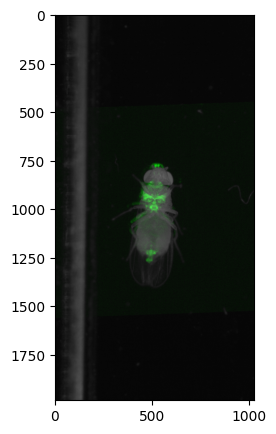

In [24]:
alpha = 0.8
behavior_image_rgb = np.repeat(behavior_image_example[:, :, np.newaxis], 3, axis=2)
muscle_image_rgb = np.zeros_like(behavior_image_rgb)
muscle_image_rgb[:, :, 1] = muscle_image_scaled
overlaid = np.maximum(alpha * behavior_image_rgb, muscle_image_rgb).astype(np.uint8)
fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(overlaid, cmap="gray", vmin=0, vmax=255)